# Household Energy Consumption Forecasting — Hourly Multi-Sensor

**Models:** Stacked BiLSTM | CNN-BiLSTM | CNN-BiLSTM + Temporal Attention

Each model uses:
- **Seq input (24h look-back):** past 24 hours of all features
- **Current input:** other sensor readings at the prediction timestep
  (Voltage, Reactive Power, Sub-meterings observed simultaneously with target)

**Target:** `Global_active_power` (kW)


## 1. Imports

In [27]:
# =======================
# Core Libraries
# =======================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# =======================
# Preprocessing & Metrics
# =======================
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# =======================
# Deep Learning (TensorFlow / Keras)
# =======================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    LSTM,
    Conv1D,
    MaxPooling1D,
    Dense,
    Dropout,
    Bidirectional,
    Multiply,
    Flatten,
    Reshape,
    Activation,
    Lambda,
    Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as keras_backend

# =======================
# Reproducibility
# =======================
random_seed = 42
tf.random.set_seed(random_seed)
np.random.seed(random_seed)

# =======================
# Environment Info
# =======================
available_gpus = tf.config.list_physical_devices("GPU")
print(f"TensorFlow {tf.__version__} — GPUs: {available_gpus}")


TensorFlow 2.20.0 — GPUs: []


## 2. Load & Preprocess

In [2]:
# =======================
# Load and preprocess dataset
# =======================
energy_data = pd.read_csv(
    "household_power_consumption.txt",
    sep=";",
    na_values=["?"],
    parse_dates={"timestamp": ["Date", "Time"]},
    low_memory=False,
)

# Set datetime index and handle missing values
energy_data = (
    energy_data
    .set_index("timestamp")
    .astype(float)
    .ffill()
    .bfill()
)

# Resample to hourly data
hourly_energy_data = energy_data.resample("h").mean().dropna()

# =======================
# Feature definitions
# =======================
target_column = "Global_active_power"

current_sensor_features = [
    "Global_reactive_power",
    "Voltage",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3",
]

# =======================
# Outlier removal (cap at 99th percentile)
# =======================
upper_bound = hourly_energy_data[target_column].quantile(0.99)

filtered_energy_data = hourly_energy_data[
    hourly_energy_data[target_column] <= upper_bound
].copy()

print(f"Rows: {len(filtered_energy_data):,}")

filtered_energy_data[
    [target_column] + current_sensor_features
].describe().round(3)

Rows: 34,243


,Global_active_power,Global_reactive_power,Voltage,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,34243.000,34243.000,34243.000,34243.000,34243.000,34243.000
mean,1.052,0.122,240.884,1.006,1.148,6.327
std,0.829,0.066,2.969,3.186,3.697,7.314
min,0.124,0.000,225.834,0.000,0.000,0.000
25%,0.340,0.077,239.249,0.000,0.000,0.650
50%,0.783,0.106,241.012,0.000,0.317,1.633
75%,1.551,0.148,242.712,0.000,0.650,13.633
max,3.921,0.774,251.902,45.300,43.933,21.550


In [3]:
filtered_energy_data.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
timestamp,,,,,,,
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667
2006-12-16 22:00:00,2.200133,0.056167,238.760000,9.523333,0.0,0.133333,4.433333


In [4]:
print("Shape:", hourly_energy_data.shape)
print("\nColumns:\n", hourly_energy_data.columns.tolist())

hourly_energy_data.info()

hourly_energy_data.describe().T.round(3)

Shape: (34589, 7)

Columns:
 ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34589 non-null  float64
 1   Global_reactive_power  34589 non-null  float64
 2   Voltage                34589 non-null  float64
 3   Global_intensity       34589 non-null  float64
 4   Sub_metering_1         34589 non-null  float64
 5   Sub_metering_2         34589 non-null  float64
 6   Sub_metering_3         34589 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


,count,mean,std,min,25%,50%,75%,max
Global_active_power,34589.0,1.086,0.895,0.124,0.341,0.800,1.575,6.561
Global_reactive_power,34589.0,0.123,0.067,0.000,0.078,0.107,0.149,0.774
Voltage,34589.0,240.842,2.999,225.834,239.197,240.984,242.692,251.902
Global_intensity,34589.0,4.604,3.746,0.503,1.510,3.407,6.583,28.383
Sub_metering_1,34589.0,1.111,3.518,0.000,0.000,0.000,0.000,48.367
Sub_metering_2,34589.0,1.288,4.169,0.000,0.000,0.333,0.650,46.433
Sub_metering_3,34589.0,6.417,7.345,0.000,0.650,1.650,14.083,21.550


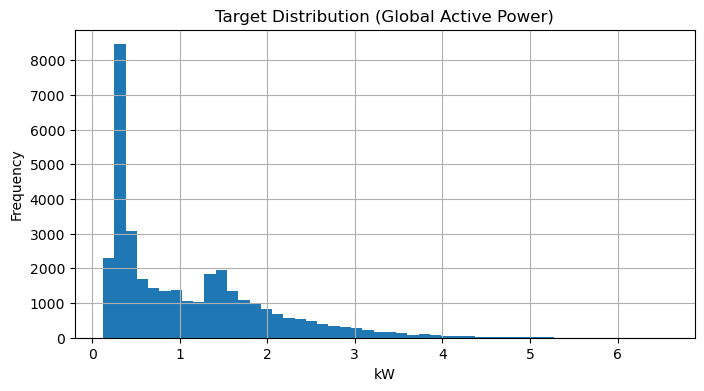

In [5]:
target_column = "Global_active_power"

plt.figure(figsize=(8, 4))
hourly_energy_data[target_column].hist(bins=50)
plt.title("Target Distribution (Global Active Power)")
plt.xlabel("kW")
plt.ylabel("Frequency")
plt.show()


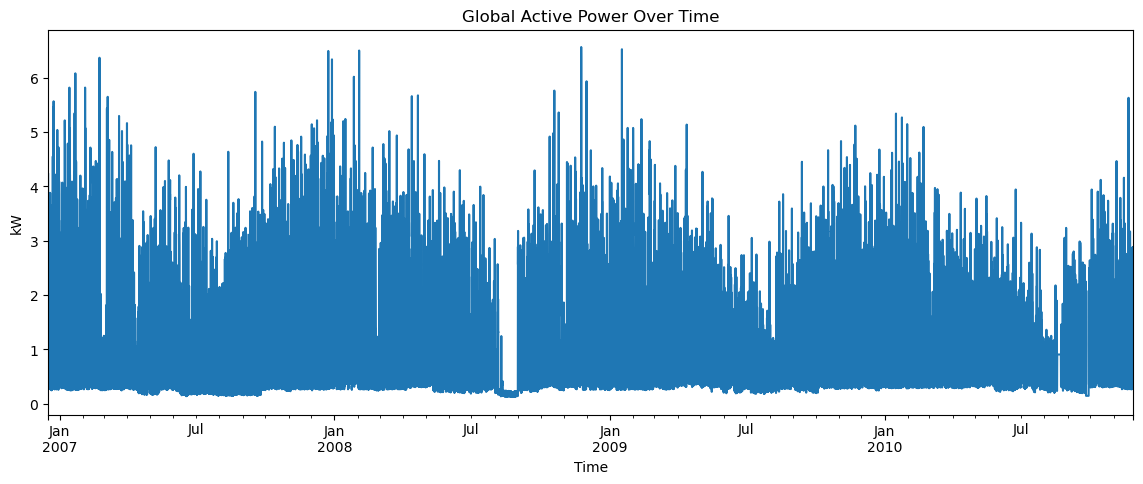

In [6]:
plt.figure(figsize=(14, 5))
hourly_energy_data[target_column].plot()
plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

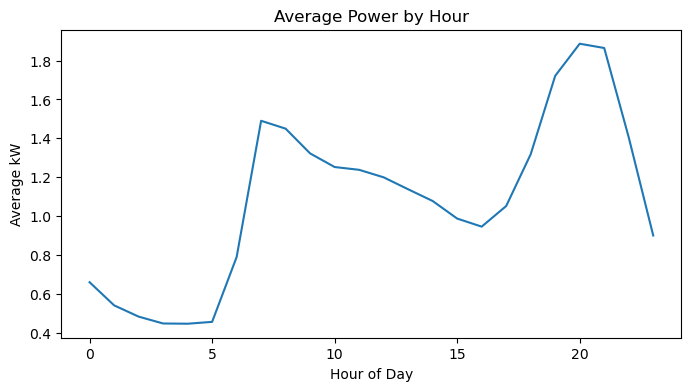

In [7]:
hourly_energy_data["hour"] = hourly_energy_data.index.hour

hourly_avg_power = (
    hourly_energy_data
    .groupby("hour")[target_column]
    .mean()
)

plt.figure(figsize=(8, 4))
hourly_avg_power.plot()
plt.title("Average Power by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average kW")
plt.show()

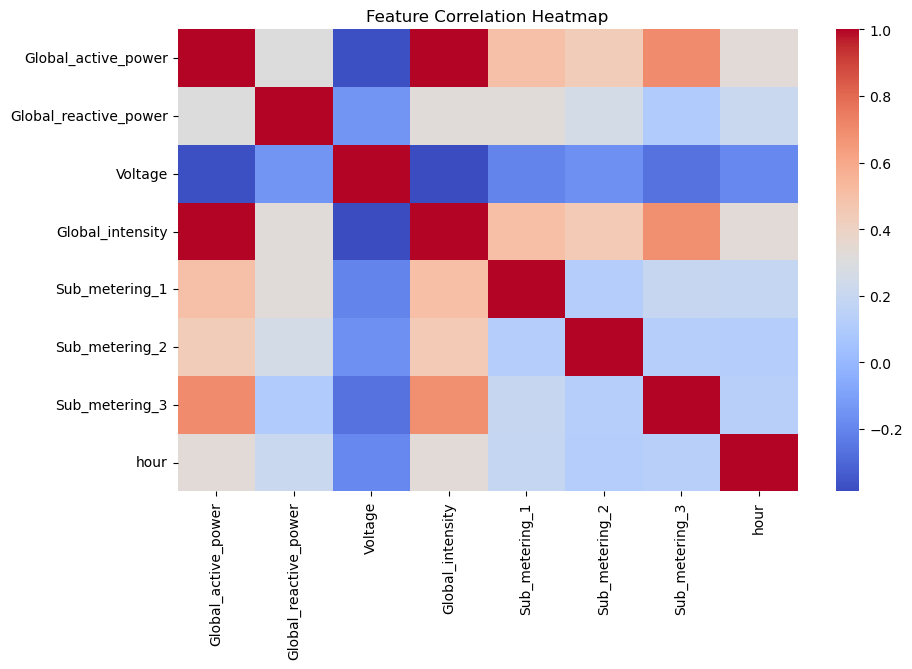

In [8]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    hourly_energy_data.corr(),
    cmap="coolwarm",
    annot=False
)
plt.title("Feature Correlation Heatmap")
plt.show()

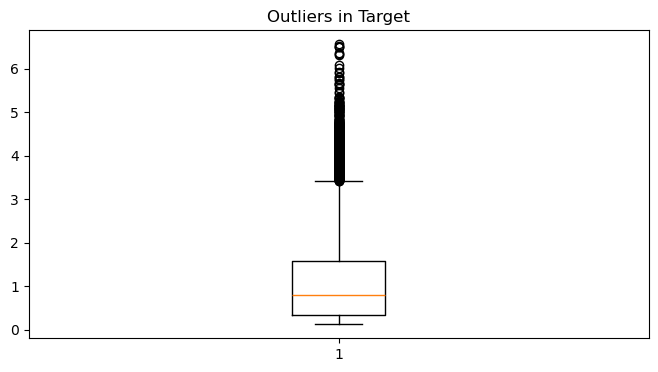

In [9]:
plt.figure(figsize=(8, 4))
plt.boxplot(hourly_energy_data[target_column])
plt.title("Outliers in Target")
plt.show()

In [10]:
# =======================
# Log transform target
# =======================
target_column = "Global_active_power"

hourly_energy_data["target_log"] = np.log1p(
    hourly_energy_data[target_column]
)

# Use transformed target from now
target_column = "target_log"


# =======================
# Drop redundant features (from correlation insight)
# =======================
hourly_energy_data = hourly_energy_data.drop(
    columns=["Global_intensity"],
    errors="ignore"
)


## 3. Feature Engineering

In [11]:
# =======================
# Calendar features
# =======================
hourly_energy_data["hour"] = hourly_energy_data.index.hour
hourly_energy_data["day_of_week"] = hourly_energy_data.index.dayofweek
hourly_energy_data["month"] = hourly_energy_data.index.month
hourly_energy_data["is_weekend"] = (
    hourly_energy_data["day_of_week"] >= 5
).astype(int)


# =======================
# Lag features (use LOG target)
# =======================
lag_hours = [1, 2, 3, 6, 12, 24, 48, 168]

for lag in lag_hours:
    hourly_energy_data[f"target_lag_{lag}h"] = (
        hourly_energy_data[target_column].shift(lag)
    )


# =======================
# Rolling features (causal)
# =======================
rolling_windows = [6, 24, 168]

for window in rolling_windows:
    hourly_energy_data[f"target_roll_mean_{window}h"] = (
        hourly_energy_data[target_column]
        .shift(1)
        .rolling(window)
        .mean()
    )
    hourly_energy_data[f"target_roll_std_{window}h"] = (
        hourly_energy_data[target_column]
        .shift(1)
        .rolling(window)
        .std()
    )


# =======================
# Final dataset after feature engineering
# =======================
feature_engineered_data = hourly_energy_data.dropna()

print(f"Final shape: {feature_engineered_data.shape}")

Final shape: (34421, 25)


## 4. Split, Scale & Sequence Construction

In [12]:
# =======================
# Configuration
# =======================
sequence_length = 24
train_fraction = 0.8

# =======================
# Feature groups
# =======================
sequence_feature_columns = (
    [target_column] +
    current_sensor_features +
    ["hour", "day_of_week", "month", "is_weekend"] +
    [
        col for col in feature_engineered_data.columns
        if col.startswith("target_lag_") or col.startswith("target_roll_")
    ]
)

target_index_in_sequence = sequence_feature_columns.index(target_column)

current_feature_columns = current_sensor_features

In [13]:
# =======================
# Convert to numpy arrays/extract raw arrays
# =======================
num_samples = len(feature_engineered_data)
train_size = int(num_samples * train_fraction)

sequence_features_array = feature_engineered_data[sequence_feature_columns].values
current_features_array = feature_engineered_data[current_feature_columns].values
target_array = feature_engineered_data[target_column].values

In [14]:
# =======================
# Scaling
# =======================
sequence_scaler = MinMaxScaler()
current_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

scaled_sequence_features = sequence_scaler.fit_transform(sequence_features_array)
scaled_current_features = current_scaler.fit_transform(current_features_array)
scaled_target = target_scaler.fit_transform(target_array.reshape(-1, 1)).ravel()

In [15]:
# =======================
# Build sequences (24-hour forecasting)
# =======================
forecast_horizon = 24

sequence_inputs = []
current_inputs = []
targets = []

for i in range(sequence_length, num_samples - forecast_horizon):
    
    # Past 24 hours
    sequence_inputs.append(
        scaled_sequence_features[i - sequence_length : i]
    )
    
    # Current features at time i
    current_inputs.append(
        scaled_current_features[i]
    )
    
    # FUTURE 24 hours target
    targets.append(
        scaled_target[i : i + forecast_horizon]
    )

sequence_inputs = np.array(sequence_inputs, dtype=np.float32)
current_inputs = np.array(current_inputs, dtype=np.float32)
targets = np.array(targets, dtype=np.float32)

In [16]:
# =======================
# Train-test split( time based)
# =======================
split_index = train_size - sequence_length

X_sequence_train = sequence_inputs[:split_index]
X_sequence_test = sequence_inputs[split_index:]

X_current_train = current_inputs[:split_index]
X_current_test = current_inputs[split_index:]

y_train = targets[:split_index]
y_test = targets[split_index:]

In [17]:
# =======================
# Shape information
# =======================
num_sequence_features = X_sequence_train.shape[2]
num_current_features = X_current_train.shape[1]

print(f"Sequence → train {X_sequence_train.shape}, test {X_sequence_test.shape}")
print(f"Current  → train {X_current_train.shape}, test {X_current_test.shape}")

Sequence → train (27512, 24, 24), test (6861, 24, 24)
Current  → train (27512, 5), test (6861, 5)


In [18]:
# =======================
# Inverse transform target (multi-step)
# =======================
def inverse_transform_target(scaled_targets):
    scaled_targets = np.array(scaled_targets)
    
    # reshape to 2D for scaler
    original_shape = scaled_targets.shape
    reshaped_targets = scaled_targets.reshape(-1, 1)
    
    # inverse scaling
    unscaled_targets = target_scaler.inverse_transform(reshaped_targets)
    
    # reshape back to original (batch, 24)
    return unscaled_targets.reshape(original_shape)

## 5. Model Definitions 

In [19]:
def build_bilstm_model(sequence_length, num_sequence_features, num_current_features, forecast_horizon=24):
    
    sequence_input = Input(shape=(sequence_length, num_sequence_features), name="sequence_input")
    current_input = Input(shape=(num_current_features,), name="current_input")

    x = Bidirectional(LSTM(128, return_sequences=True))(sequence_input)
    x = Dropout(0.2)(x)
    
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.2)(x)
    
    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.2)(x)

    merged = Concatenate()([x, current_input])

    x = Dense(64, activation="relu")(merged)
    x = Dense(32, activation="relu")(x)

    output = Dense(forecast_horizon, name="forecast_output")(x)

    return Model(inputs=[sequence_input, current_input], outputs=output, name="bilstm_model")

In [20]:
def build_cnn_bilstm_model(sequence_length, num_sequence_features, num_current_features, forecast_horizon=24):
    
    sequence_input = Input(shape=(sequence_length, num_sequence_features), name="sequence_input")
    current_input = Input(shape=(num_current_features,), name="current_input")

    x = Conv1D(128, 3, activation="relu", padding="same")(sequence_input)
    x = Conv1D(128, 3, activation="relu", padding="same")(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(64))(x)
    x = Dropout(0.2)(x)

    merged = Concatenate()([x, current_input])

    x = Dense(64, activation="relu")(merged)
    x = Dense(32, activation="relu")(x)

    output = Dense(forecast_horizon, name="forecast_output")(x)

    return Model(inputs=[sequence_input, current_input], outputs=output, name="cnn_bilstm_model")

In [29]:
def build_attention_model(sequence_length, num_sequence_features, num_current_features, forecast_horizon=24):
    
    sequence_input = Input(shape=(sequence_length, num_sequence_features), name="sequence_input")
    current_input = Input(shape=(num_current_features,), name="current_input")

    x = Conv1D(128, 3, activation="relu", padding="same")(sequence_input)
    x = Conv1D(128, 3, activation="relu", padding="same")(x)
    x = Dropout(0.2)(x)

    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = Dropout(0.2)(x)

    # ===== Attention =====
    attention_scores = Dense(1, activation="tanh")(x)
    attention_scores = Flatten()(attention_scores)
    
    attention_weights = Activation("softmax", name="attention_weights")(attention_scores)
    attention_weights = Reshape((sequence_length, 1))(attention_weights)

    from tensorflow.keras.layers import GlobalAveragePooling1D

    context_vector = Multiply()([x, attention_weights])
    context_vector = GlobalAveragePooling1D()(context_vector)

    # Merge with current features
    merged = Concatenate()([context_vector, current_input])

    x = Dense(64, activation="relu")(merged)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)

    output = Dense(forecast_horizon, name="forecast_output")(x)

    return Model(inputs=[sequence_input, current_input], outputs=output, name="cnn_bilstm_attention_model")

In [22]:
def compile_model(model):
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"]
    )
    return model


In [33]:
training_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        patience=5,
        factor=0.5,
        min_lr=1e-6,
        verbose=1
    )
]
def train_model(model, model_name):
    
    print(f"\n🚀 Training {model_name}...\n")

    history = model.fit(
        [X_sequence_train, X_current_train],
        y_train,
        validation_data=([X_sequence_test, X_current_test], y_test),
        epochs=50,
        batch_size=32,
        callbacks=training_callbacks,
        verbose=1
    )

    return history


In [45]:
##6. BUilding models 

In [34]:
# =======================
# Build models
# =======================
bilstm_model = compile_model(
    build_bilstm_model(sequence_length, num_sequence_features, num_current_features)
)

cnn_bilstm_model = compile_model(
    build_cnn_bilstm_model(sequence_length, num_sequence_features, num_current_features)
)

attention_model = compile_model(
    build_attention_model(sequence_length, num_sequence_features, num_current_features)
)


# =======================
# Train models
# =======================
bilstm_history = train_model(bilstm_model, "BiLSTM")

cnn_bilstm_history = train_model(cnn_bilstm_model, "CNN-BiLSTM")

attention_history = train_model(attention_model, "CNN-BiLSTM-Attention")


🚀 Training BiLSTM...

Epoch 1/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 105s 91ms/step - loss: 0.0305 - mae: 0.1378 - val_loss: 0.0210 - val_mae: 0.1105 - learning_rate: 0.0010
Epoch 2/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - loss: 0.0234 - mae: 0.1186 - val_loss: 0.0200 - val_mae: 0.1066 - learning_rate: 0.0010
Epoch 3/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 75s 87ms/step - loss: 0.0218 - mae: 0.1137 - val_loss: 0.0202 - val_mae: 0.1060 - learning_rate: 0.0010
Epoch 4/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 76s 88ms/step - loss: 0.0204 - mae: 0.1096 - val_loss: 0.0200 - val_mae: 0.1058 - learning_rate: 0.0010
Epoch 5/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 76s 88ms/step - loss: 0.0192 - mae: 0.1058 - val_loss: 0.0209 - val_mae: 0.1073 - learning_rate: 0.0010
Epoch 6/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 78s 91ms/step - loss: 0.0179 - mae: 0.1020 - val_loss: 0.0211 - val_mae: 0.1077 - learning_rate: 0.0010
Epoch 7/50
860/860 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0170 - mae: 0.0991  
Epoch 7: ReduceLROnPlateau r

In [37]:
# =======================
# Convert to real kW + Metrics
# =======================
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Predict (scaled)
y_pred_scaled = attention_model.predict([X_sequence_test, X_current_test])

# Inverse scaling
y_pred_unscaled = inverse_transform_target(y_pred_scaled)
y_true_unscaled = inverse_transform_target(y_test)

# Reverse log transform → kW
y_pred_kw = np.expm1(y_pred_unscaled)
y_true_kw = np.expm1(y_true_unscaled)

# Flatten for overall metrics
y_pred_flat = y_pred_kw.flatten()
y_true_flat = y_true_kw.flatten()

# Metrics
overall_mae = mean_absolute_error(y_true_flat, y_pred_flat)

print(f"Overall MAE (kW): {overall_mae:.4f}")


215/215 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
Overall MAE (kW): 0.4165


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

per_hour_mae = []
per_hour_rmse = []

for h in range(24):
    y_true_h = y_true_kw[:, h]
    y_pred_h = y_pred_kw[:, h]

    mae_h = mean_absolute_error(y_true_h, y_pred_h)
    rmse_h = np.sqrt(mean_squared_error(y_true_h, y_pred_h))

    per_hour_mae.append(mae_h)
    per_hour_rmse.append(rmse_h)

for i in range(24):
    print(f"Hour {i+1:02d}: MAE = {per_hour_mae[i]:.4f} kW | RMSE = {per_hour_rmse[i]:.4f} kW")

Hour 01: MAE = 0.1937 kW | RMSE = 0.2876 kW
Hour 02: MAE = 0.3706 kW | RMSE = 0.5291 kW
Hour 03: MAE = 0.4083 kW | RMSE = 0.5746 kW
Hour 04: MAE = 0.4187 kW | RMSE = 0.5945 kW
Hour 05: MAE = 0.4208 kW | RMSE = 0.6025 kW
Hour 06: MAE = 0.4221 kW | RMSE = 0.6109 kW
Hour 07: MAE = 0.4218 kW | RMSE = 0.6133 kW
Hour 08: MAE = 0.4280 kW | RMSE = 0.6132 kW
Hour 09: MAE = 0.4281 kW | RMSE = 0.6150 kW
Hour 10: MAE = 0.4296 kW | RMSE = 0.6174 kW
Hour 11: MAE = 0.4292 kW | RMSE = 0.6109 kW
Hour 12: MAE = 0.4313 kW | RMSE = 0.6114 kW
Hour 13: MAE = 0.4327 kW | RMSE = 0.6132 kW
Hour 14: MAE = 0.4318 kW | RMSE = 0.6183 kW
Hour 15: MAE = 0.4338 kW | RMSE = 0.6184 kW
Hour 16: MAE = 0.4332 kW | RMSE = 0.6167 kW
Hour 17: MAE = 0.4310 kW | RMSE = 0.6177 kW
Hour 18: MAE = 0.4282 kW | RMSE = 0.6196 kW
Hour 19: MAE = 0.4300 kW | RMSE = 0.6252 kW
Hour 20: MAE = 0.4283 kW | RMSE = 0.6189 kW
Hour 21: MAE = 0.4343 kW | RMSE = 0.6199 kW
Hour 22: MAE = 0.4361 kW | RMSE = 0.6170 kW
Hour 23: MAE = 0.4365 kW | RMSE 

In [40]:
# =======================
# Sample prediction (single example)
# =======================
import matplotlib.pyplot as plt
import numpy as np

# pick any test sample
sample_index = 0   # change this to see different examples

# Get inputs
seq_sample = X_sequence_test[sample_index:sample_index+1]
curr_sample = X_current_test[sample_index:sample_index+1]

# Predict (scaled)
pred_scaled = attention_model.predict([seq_sample, curr_sample])

# Convert back to real values
pred_unscaled = inverse_transform_target(pred_scaled)
true_unscaled = inverse_transform_target(y_test[sample_index:sample_index+1])

pred_kw = np.expm1(pred_unscaled).flatten()
true_kw = np.expm1(true_unscaled).flatten()

# =======================
# Print values
# =======================
print("Hour | Actual (kW) | Predicted (kW)")
print("-" * 35)

for i in range(24):
    print(f"{i+1:02d}   | {true_kw[i]:.3f}       | {pred_kw[i]:.3f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Hour | Actual (kW) | Predicted (kW)
-----------------------------------
01   | 0.331       | 0.319
02   | 0.287       | 0.321
03   | 0.292       | 0.378
04   | 0.337       | 0.384
05   | 0.357       | 0.481
06   | 1.143       | 0.699
07   | 1.964       | 1.081
08   | 2.062       | 1.478
09   | 1.939       | 1.528
10   | 2.643       | 1.523
11   | 1.503       | 1.589
12   | 3.924       | 1.693
13   | 3.272       | 1.733
14   | 4.174       | 1.669
15   | 2.006       | 1.754
16   | 1.604       | 1.809
17   | 1.579       | 1.956
18   | 1.564       | 2.282
19   | 1.528       | 2.397
20   | 1.588       | 2.633
21   | 1.640       | 2.533
22   | 1.554       | 2.101
23   | 1.584       | 1.635
24   | 1.595       | 1.119


## 10. Actual vs Predicted

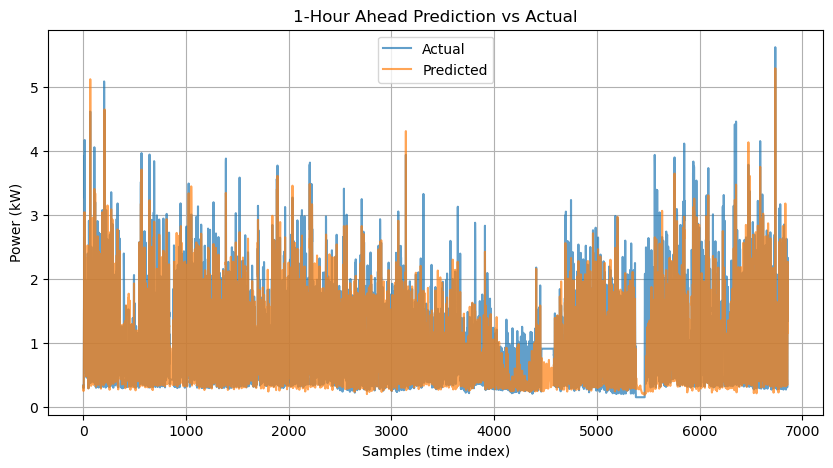

In [41]:
# =======================
# Plot 1-hour ahead predictions
# =======================
import matplotlib.pyplot as plt

# Hour 1 = index 0
hour = 0

y_true_h1 = y_true_kw[:, hour]
y_pred_h1 = y_pred_kw[:, hour]

plt.figure(figsize=(10,5))

plt.plot(y_true_h1, label="Actual", alpha=0.7)
plt.plot(y_pred_h1, label="Predicted", alpha=0.7)

plt.title("1-Hour Ahead Prediction vs Actual")
plt.xlabel("Samples (time index)")
plt.ylabel("Power (kW)")
plt.legend()
plt.grid()

plt.show()